<a href="https://colab.research.google.com/github/dalga04/global-health-risk-prediction/blob/main/global_health_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Preprocessing + Feature Engineering

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

def validate_dataset(df, name=""):
    print(f"\n=== Dataset Validation: {name} ===")
    print("Rows:", df.shape[0], " | Columns:", df.shape[1])
    print("Total Missing:", df.isnull().sum().sum())
    print("Duplicate Rows:", df.duplicated().sum())

    return True


def impute_missing(df):
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include=np.number).columns
    for col in num_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    return df_clean


def handle_outliers(df):
    df_new = df.copy()
    num_cols = df_new.select_dtypes(include=np.number).columns

    for col in num_cols:
        q1, q3 = df_new[col].quantile(0.25), df_new[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        df_new[col] = df_new[col].clip(lower, upper)

    return df_new


def feature_engineering(df):
    df = df.copy()

    if 'bmi' in df.columns:
        df['bmi_category'] = pd.cut(
            df['bmi'],
            bins=[0, 18.5, 24.9, 29.9, 100],
            labels=['Underweight', 'Normal', 'Overweight', 'Obese']
        )

    if 'daily_steps' in df.columns:
        df['activity_level'] = pd.cut(
            df['daily_steps'],
            bins=[0, 5000, 8000, 12000, 50000],
            labels=['Low', 'Average', 'Active', 'Highly Active']
        )

    if {'bmi', 'age'}.issubset(df.columns):
        df['health_risk_score'] = (
            df['bmi'] * 0.4 + df['age'] * 0.6
        ) / 10

    return df


def scale_numeric(df):
    df_scaled = df.copy()
    numeric_cols = df_scaled.select_dtypes(include=np.number).columns
    scaler = StandardScaler()
    df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])
    return df_scaled

#2. Data Integration

In [16]:
import pandas as pd

def integrate_datasets(df1, df2):
    df1 = df1.copy()
    df2 = df2.copy()

    df1['source'] = 'global_health'
    df2['source'] = 'lifestyle'

    df1['id'] = range(1, len(df1) + 1)
    df2['id'] = range(1, len(df2) + 1)

    integrated = pd.concat([df1, df2], ignore_index=True, sort=False)
    integrated.to_csv("integrated_dataset.csv", index=False)

    return integrated

#3. Machine Learning Model (Random Forest)

Model Accuracy: 75.22%
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     15042
           1       0.75      0.00      0.00      4958

    accuracy                           0.75     20000
   macro avg       0.75      0.50      0.43     20000
weighted avg       0.75      0.75      0.65     20000



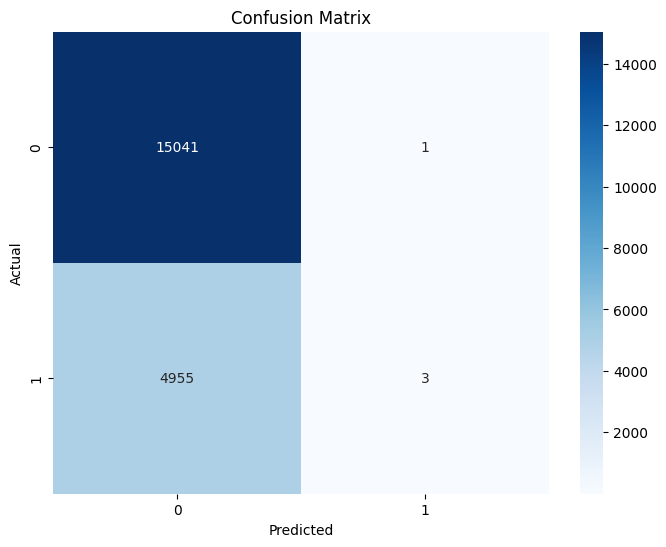

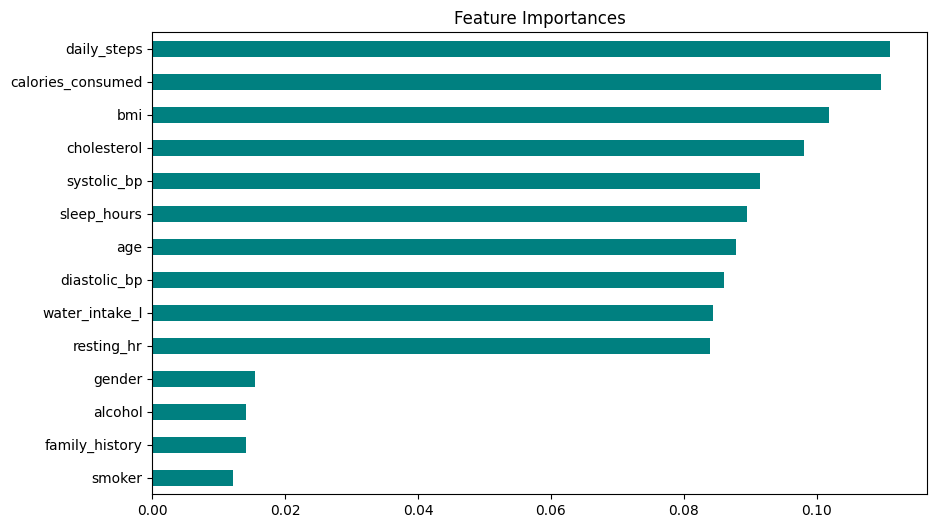

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load datasets
data1 = pd.read_csv('Global Health Statistics.csv.gz')
data2 = pd.read_csv('health_lifestyle_dataset.csv')

# Encoding categorical features
le = LabelEncoder()
data2_encoded = data2.copy()

categorical_cols = ['gender', 'smoker', 'alcohol', 'family_history']

for col in categorical_cols:
    data2_encoded[col] = le.fit_transform(data2_encoded[col].astype(str))

# Features & target
X = data2_encoded.drop(columns=['id', 'disease_risk'])
y = data2_encoded['disease_risk']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importances')
plt.show()